<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula11a_self_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### O problema de modelar longas sequências

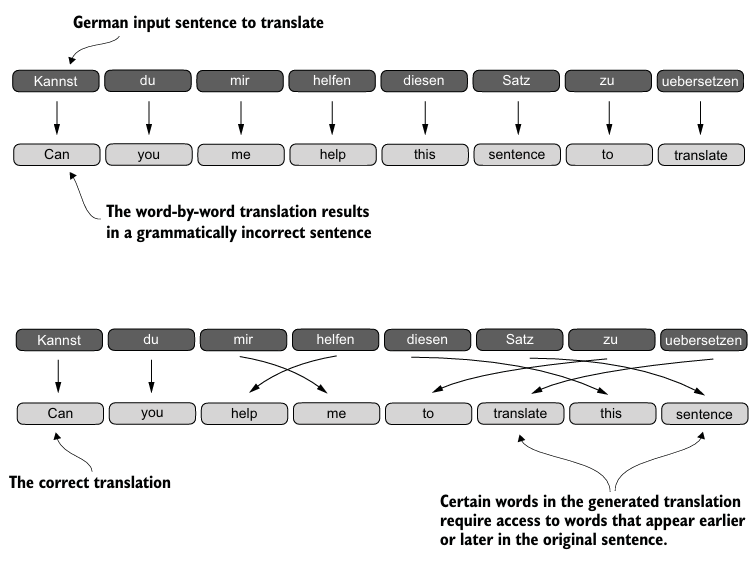

### Encoder e decoder em uma rede recorrente

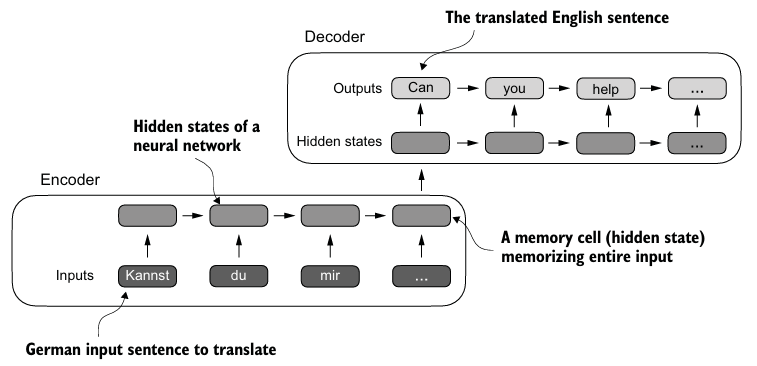

### Rede recorrente com attention (Bahdanau attention)

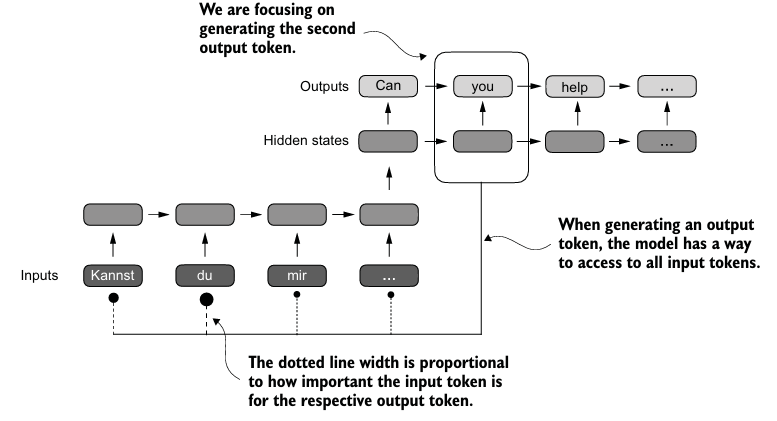

### self-attention sem treinamento

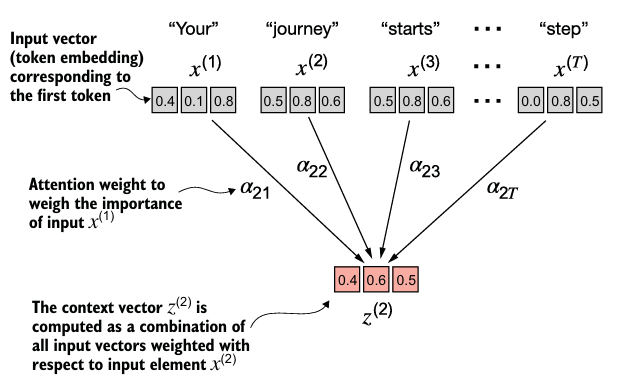

In [1]:
import numpy as np
from pprint import pprint

inputs = np.array(
  [[0.43, 0.15, 0.89], # Your (x^1)
   [0.55, 0.87, 0.66], # journey (x^2)
   [0.57, 0.85, 0.64], # starts (x^3)
   [0.22, 0.58, 0.33], # with (x^4)
   [0.77, 0.25, 0.10], # one (x^5)
   [0.05, 0.80, 0.55]] # step (x^6)
)
pprint(inputs)

array([[0.43, 0.15, 0.89],
       [0.55, 0.87, 0.66],
       [0.57, 0.85, 0.64],
       [0.22, 0.58, 0.33],
       [0.77, 0.25, 0.1 ],
       [0.05, 0.8 , 0.55]])


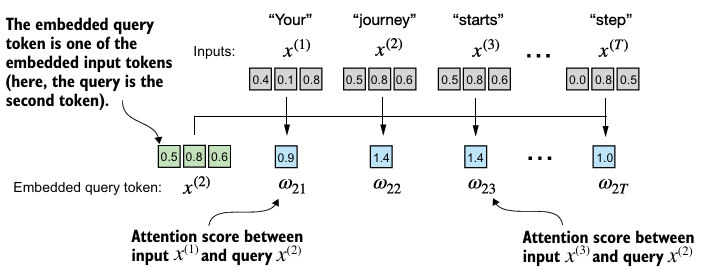

### attention scores

In [3]:
query = inputs[1]
attn_scores_2 = np.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
  attn_scores_2[i] = np.dot(x_i, query)
print(attn_scores_2)

[0.9544 1.495  1.4754 0.8434 0.707  1.0865]


### attention weights

In [4]:
attn_weights_2 = attn_scores_2 / attn_scores_2.sum()
print(attn_weights_2)
print(np.sum(attn_weights_2))

[0.14545011 0.2278373  0.22485027 0.12853376 0.10774647 0.16558209]
1.0


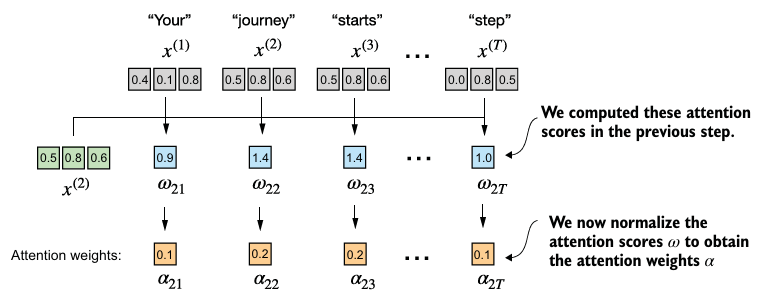

### softmax normalization

In [5]:
def softmax_naive(x):
  return np.exp(x) / np.exp(x).sum(axis=0)
attn_weights_2 = softmax_naive(attn_scores_2)
print(attn_weights_2)
print(attn_weights_2.sum())

[0.13854759 0.2378913  0.23327403 0.1239916  0.10818188 0.15811361]
1.0000000000000002


### stable implementation

In [6]:
from scipy.special import softmax

attn_weights_2 = softmax(attn_scores_2)
print(attn_weights_2)
print(attn_weights_2.sum())

[0.13854759 0.2378913  0.23327403 0.1239916  0.10818188 0.15811361]
1.0


### context vector

In [7]:
query = inputs[1]
context_vec_2 = np.zeros(query.shape)
for i, x_i in enumerate(inputs):
  context_vec_2 += attn_weights_2[i] * x_i
print(context_vec_2)

[0.44186575 0.65148198 0.56830889]


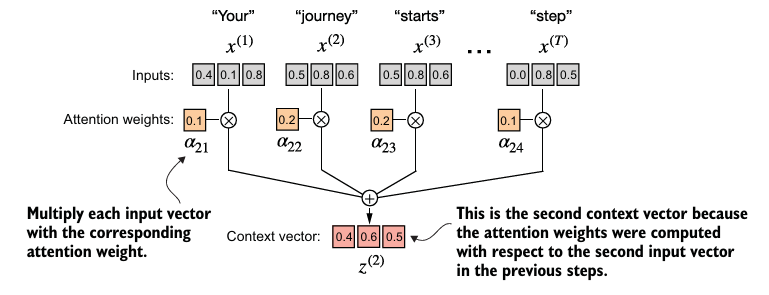

### context matrix

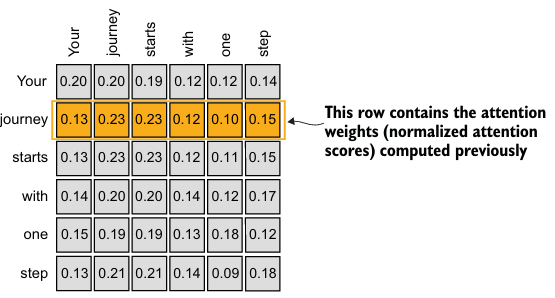

In [8]:
attn_scores = np.empty((len(inputs), len(inputs)))
for i, x_i in enumerate(inputs):
  for j, x_j in enumerate(inputs):
    attn_scores[i, j] = np.dot(x_i, x_j)
print(attn_scores)

[[0.9995 0.9544 0.9422 0.4753 0.4576 0.631 ]
 [0.9544 1.495  1.4754 0.8434 0.707  1.0865]
 [0.9422 1.4754 1.457  0.8296 0.7154 1.0605]
 [0.4753 0.8434 0.8296 0.4937 0.3474 0.6565]
 [0.4576 0.707  0.7154 0.3474 0.6654 0.2935]
 [0.631  1.0865 1.0605 0.6565 0.2935 0.945 ]]


In [9]:
print(attn_scores_2)

[0.9544 1.495  1.4754 0.8434 0.707  1.0865]


In [10]:
attn_scores = inputs @ inputs.T
print(attn_scores)

[[0.9995 0.9544 0.9422 0.4753 0.4576 0.631 ]
 [0.9544 1.495  1.4754 0.8434 0.707  1.0865]
 [0.9422 1.4754 1.457  0.8296 0.7154 1.0605]
 [0.4753 0.8434 0.8296 0.4937 0.3474 0.6565]
 [0.4576 0.707  0.7154 0.3474 0.6654 0.2935]
 [0.631  1.0865 1.0605 0.6565 0.2935 0.945 ]]


In [11]:
attn_weights = softmax(attn_scores, axis=-1)
print(attn_weights)

[[0.20983476 0.20058144 0.19814921 0.12422822 0.12204873 0.14515764]
 [0.13854759 0.2378913  0.23327403 0.1239916  0.10818188 0.15811361]
 [0.1390076  0.23692144 0.23260194 0.1242044  0.1108002  0.15646441]
 [0.14352688 0.20739442 0.20455203 0.14619223 0.12629524 0.1720392 ]
 [0.15261084 0.19583866 0.19749064 0.13668666 0.18785891 0.12951428]
 [0.13847116 0.21836371 0.21275943 0.14204758 0.09880637 0.18955175]]


In [12]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

[[0.4420594  0.59309856 0.57898907]
 [0.44186575 0.65148198 0.56830889]
 [0.44312751 0.64959458 0.56707306]
 [0.43038973 0.62982806 0.55102706]
 [0.46710173 0.59099273 0.52659652]
 [0.41772447 0.65032321 0.56453522]]


In [13]:
print(context_vec_2)

[0.44186575 0.65148198 0.56830889]
